In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn  
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_squared_error, r2_score, roc_curve, auc,
                           accuracy_score, confusion_matrix, classification_report,
                           precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Все библиотеки загружены!")
print(f"Scikit-learn version: {sklearn.__version__}") 

Все библиотеки загружены!
Scikit-learn version: 1.8.0


In [35]:
df = pd.read_csv('processed_titanic-checkpoint.csv')

In [37]:
feature_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

if 'Sex_male' in df.columns:
    feature_cols.append('Sex_male')
if 'Embarked_Q' in df.columns:
    feature_cols.append('Embarked_Q')
if 'Embarked_S' in df.columns:
    feature_cols.append('Embarked_S')

available_cols = [col for col in feature_cols if col in df.columns]
X = df[available_cols].copy()
y_clf = df['Survived'] 
y_reg = df['Fare']      

print("Обработка пропусков в признаках:")
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f"  Заполнены пропуски в '{col}' медианой {median_val}")

print(f"\nКоличество признаков: {X.shape[1]}")
print(f"Признаки: {list(X.columns)}")
print(f"\nРаспределение целевой переменной (классификация - выживание):")
display(y_clf.value_counts())
print(f"\nСтатистика целевой переменной (регрессия - стоимость билета):")
display(y_reg.describe())

Обработка пропусков в признаках:
  Заполнены пропуски в 'Age' медианой 28.0

Количество признаков: 5
Признаки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Распределение целевой переменной (классификация - выживание):


Survived
0    549
1    342
Name: count, dtype: int64


Статистика целевой переменной (регрессия - стоимость билета):


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [38]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.3, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

print("РАЗМЕРЫ ВЫБОРОК")
print(f"Регрессия - обучающая выборка: {X_train_reg.shape}")
print(f"Регрессия - тестовая выборка: {X_test_reg.shape}")
print(f"\nКлассификация - обучающая выборка: {X_train_clf.shape}")
print(f"Классификация - тестовая выборка: {X_test_clf.shape}")
print(f"\nРаспределение классов в обучающей выборке (выживание):")
print(y_train_clf.value_counts(normalize=True))
print(f"\nРаспределение классов в тестовой выборке (выживание):")
print(y_test_clf.value_counts(normalize=True))

РАЗМЕРЫ ВЫБОРОК
Регрессия - обучающая выборка: (623, 5)
Регрессия - тестовая выборка: (268, 5)

Классификация - обучающая выборка: (623, 5)
Классификация - тестовая выборка: (268, 5)

Распределение классов в обучающей выборке (выживание):
Survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64

Распределение классов в тестовой выборке (выживание):
Survived
0    0.615672
1    0.384328
Name: proportion, dtype: float64


In [44]:
print("РЕШЕНИЕ ЗАДАЧИ РЕГРЕССИИ (предсказание стоимости билета)")

depths = [2, 3, 4, 5, 6, 7, 8, 10, 12]
regression_results = []

for depth in depths:
    regressor = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    regressor.fit(X_train_reg, y_train_reg)
    
    y_pred_train = regressor.predict(X_train_reg)
    y_pred_test = regressor.predict(X_test_reg)
    
    mse_train = mean_squared_error(y_train_reg, y_pred_train)
    mse_test = mean_squared_error(y_test_reg, y_pred_test)
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    mae_train = mean_absolute_error(y_train_reg, y_pred_train)
    mae_test = mean_absolute_error(y_test_reg, y_pred_test)
    
    regression_results.append({
        'depth': depth,
        'mse_train': mse_train,
        'mse_test': mse_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'mae_train': mae_train,
        'mae_test': mae_test
    })
    
    print(f"\nГлубина дерева: {depth}")
    print(f"  MSE на обучении: {mse_train:.4f}")
    print(f"  MSE на тесте: {mse_test:.4f}")
    print(f"  RMSE на обучении: {rmse_train:.4f}")
    print(f"  RMSE на тесте: {rmse_test:.4f}")
    print(f"  MAE на обучении: {mae_train:.4f}")
    print(f"  MAE на тесте: {mae_test:.4f}")

РЕШЕНИЕ ЗАДАЧИ РЕГРЕССИИ (предсказание стоимости билета)

Глубина дерева: 2
  MSE на обучении: 203.4590
  MSE на тесте: 270.5781
  RMSE на обучении: 14.2639
  RMSE на тесте: 16.4493
  MAE на обучении: 10.0503
  MAE на тесте: 11.5543

Глубина дерева: 3
  MSE на обучении: 43.2562
  MSE на тесте: 43.8291
  RMSE на обучении: 6.5769
  RMSE на тесте: 6.6204
  MAE на обучении: 4.5432
  MAE на тесте: 4.2927

Глубина дерева: 4
  MSE на обучении: 8.1773
  MSE на тесте: 25.7371
  RMSE на обучении: 2.8596
  RMSE на тесте: 5.0732
  MAE на обучении: 1.9163
  MAE на тесте: 2.4059

Глубина дерева: 5
  MSE на обучении: 1.9336
  MSE на тесте: 15.1765
  RMSE на обучении: 1.3905
  RMSE на тесте: 3.8957
  MAE на обучении: 0.9920
  MAE на тесте: 1.4296

Глубина дерева: 6
  MSE на обучении: 0.4643
  MSE на тесте: 2.5504
  RMSE на обучении: 0.6814
  RMSE на тесте: 1.5970
  MAE на обучении: 0.4736
  MAE на тесте: 0.7042

Глубина дерева: 7
  MSE на обучении: 0.1573
  MSE на тесте: 13.3902
  RMSE на обучении: 0.

In [45]:
best_reg_idx = np.argmin([res['mse_test'] for res in regression_results])
best_depth_reg = regression_results[best_reg_idx]['depth']
print(f"Лучшая глубина для регрессии: {best_depth_reg}")

best_regressor = DecisionTreeRegressor(
    max_depth=best_depth_reg,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
best_regressor.fit(X_train_reg, y_train_reg)
y_pred_reg = best_regressor.predict(X_test_reg)

mse_best = mean_squared_error(y_test_reg, y_pred_reg)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"\nЛучшая модель регрессии (глубина={best_depth_reg}):")
print(f"  MSE: {mse_best:.4f}")
print(f"  RMSE: {rmse_best:.4f}")
print(f"  MAE: {mae_best:.4f}")

Лучшая глубина для регрессии: 10

Лучшая модель регрессии (глубина=10):
  MSE: 2.1149
  RMSE: 1.4543
  MAE: 0.3014


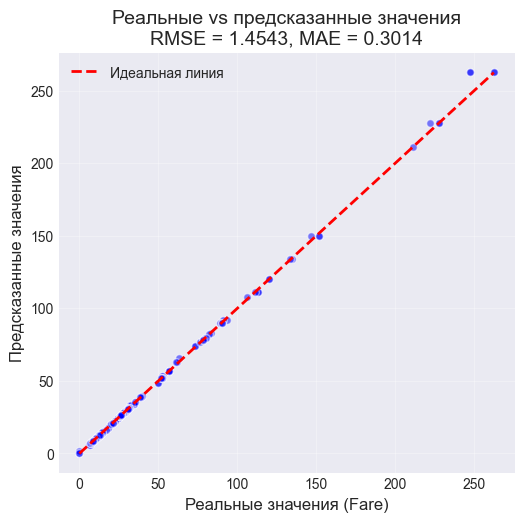

In [47]:
fig = plt.figure(figsize=(20, 12))

ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test_reg, y_pred_reg, alpha=0.5, s=30, c='blue', edgecolors='white')
ax1.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Идеальная линия')
ax1.set_xlabel('Реальные значения (Fare)', fontsize=12)
ax1.set_ylabel('Предсказанные значения', fontsize=12)
ax1.set_title(f'Реальные vs предсказанные значения\nRMSE = {rmse_best:.4f}, MAE = {mae_best:.4f}', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

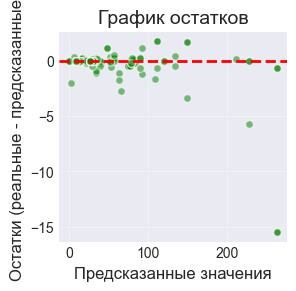

In [50]:
ax2 = plt.subplot(2, 3, 2)
residuals = y_test_reg - y_pred_reg
ax2.scatter(y_pred_reg, residuals, alpha=0.5, s=30, c='green', edgecolors='white')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Предсказанные значения', fontsize=12)
ax2.set_ylabel('Остатки (реальные - предсказанные)', fontsize=12)
ax2.set_title('График остатков', fontsize=14)
ax2.grid(True, alpha=0.3)

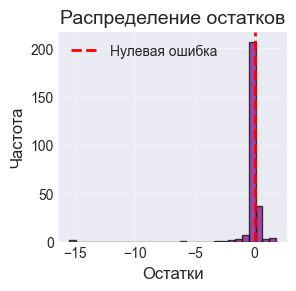

In [52]:
ax3 = plt.subplot(2, 3, 3)
ax3.hist(residuals, bins=30, alpha=0.7, color='purple', edgecolor='black')
ax3.axvline(x=0, color='r', linestyle='--', lw=2, label='Нулевая ошибка')
ax3.set_xlabel('Остатки', fontsize=12)
ax3.set_ylabel('Частота', fontsize=12)
ax3.set_title('Распределение остатков', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)

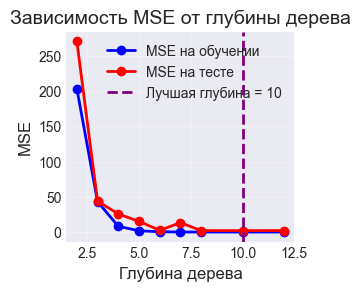

In [54]:
ax4 = plt.subplot(2, 3, 4)
reg_results_df = pd.DataFrame(regression_results)
ax4.plot(reg_results_df['depth'], reg_results_df['mse_train'], 
         'b-o', label='MSE на обучении', markersize=6, linewidth=2)
ax4.plot(reg_results_df['depth'], reg_results_df['mse_test'], 
         'r-o', label='MSE на тесте', markersize=6, linewidth=2)
ax4.axvline(x=best_depth_reg, color='purple', linestyle='--', 
            label=f'Лучшая глубина = {best_depth_reg}', linewidth=2)
ax4.set_xlabel('Глубина дерева', fontsize=12)
ax4.set_ylabel('MSE', fontsize=12)
ax4.set_title('Зависимость MSE от глубины дерева', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

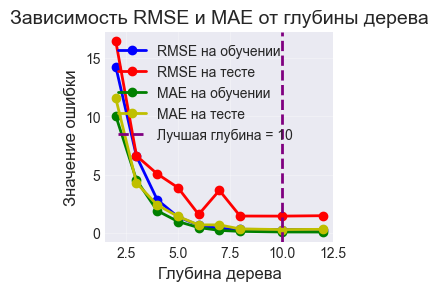

In [58]:
ax5 = plt.subplot(2, 3, 5)
ax5.plot(reg_results_df['depth'], reg_results_df['rmse_train'], 
         'b-o', label='RMSE на обучении', markersize=6, linewidth=2)
ax5.plot(reg_results_df['depth'], reg_results_df['rmse_test'], 
         'r-o', label='RMSE на тесте', markersize=6, linewidth=2)
ax5.plot(reg_results_df['depth'], reg_results_df['mae_train'], 
         'g-o', label='MAE на обучении', markersize=6, linewidth=2)
ax5.plot(reg_results_df['depth'], reg_results_df['mae_test'], 
         'y-o', label='MAE на тесте', markersize=6, linewidth=2)
ax5.axvline(x=best_depth_reg, color='purple', linestyle='--', 
            label=f'Лучшая глубина = {best_depth_reg}', linewidth=2)
ax5.set_xlabel('Глубина дерева', fontsize=12)
ax5.set_ylabel('Значение ошибки', fontsize=12)
ax5.set_title('Зависимость RMSE и MAE от глубины дерева', fontsize=14)
ax5.legend(loc='upper left')
ax5.grid(True, alpha=0.3)

СРАВНЕНИЕ ДЕРЕВА РЕШЕНИЙ С ЛИНЕЙНОЙ РЕГРЕССИЕЙ

Линейная регрессия:
  MSE: 0.0000
  RMSE: 0.0000
  MAE: 0.0000

Дерево решений (глубина=10):
  MSE: 2.1149
  RMSE: 1.4543
  MAE: 0.3014


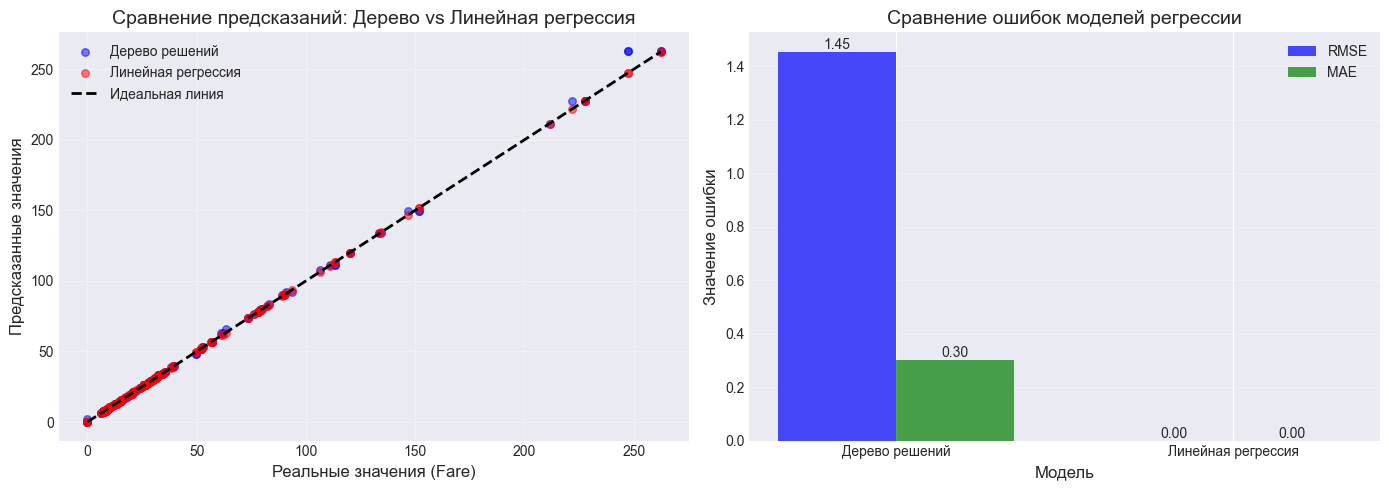

ВЫВОДЫ ПО РЕГРЕССИИ:
✓ Линейная регрессия показывает лучшие результаты, чем дерево решений
  - RMSE дерева: 1.4543 > 0.0000 (линейной)

Преимущества дерева решений для регрессии:
  • Не требует нормализации данных
  • Интерпретируемость (можно визуализировать дерево)
  • Может выявлять нелинейные зависимости
  • Устойчив к выбросам


In [60]:
print("СРАВНЕНИЕ ДЕРЕВА РЕШЕНИЙ С ЛИНЕЙНОЙ РЕГРЕССИЕЙ")

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_scaled = scaler_reg.transform(X_test_reg)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_scaled)

mse_lin = mean_squared_error(y_test_reg, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin)

print(f"\nЛинейная регрессия:")
print(f"  MSE: {mse_lin:.4f}")
print(f"  RMSE: {rmse_lin:.4f}")
print(f"  MAE: {mae_lin:.4f}")

print(f"\nДерево решений (глубина={best_depth_reg}):")
print(f"  MSE: {mse_best:.4f}")
print(f"  RMSE: {rmse_best:.4f}")
print(f"  MAE: {mae_best:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.5, s=30, c='blue', label='Дерево решений')
axes[0].scatter(y_test_reg, y_pred_lin, alpha=0.5, s=30, c='red', label='Линейная регрессия')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], 
             [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2, label='Идеальная линия')
axes[0].set_xlabel('Реальные значения (Fare)', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title('Сравнение предсказаний: Дерево vs Линейная регрессия', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

models = ['Дерево решений', 'Линейная регрессия']
rmse_values = [rmse_best, rmse_lin]
mae_values = [mae_best, mae_lin]

x = np.arange(len(models))
width = 0.35

bars1 = axes[1].bar(x - width/2, rmse_values, width, label='RMSE', color='blue', alpha=0.7)
bars2 = axes[1].bar(x + width/2, mae_values, width, label='MAE', color='green', alpha=0.7)

axes[1].set_xlabel('Модель', fontsize=12)
axes[1].set_ylabel('Значение ошибки', fontsize=12)
axes[1].set_title('Сравнение ошибок моделей регрессии', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("ВЫВОДЫ ПО РЕГРЕССИИ:")
if rmse_best < rmse_lin:
    print("✓ Дерево решений показывает лучшие результаты, чем линейная регрессия")
    print(f"  - RMSE дерева: {rmse_best:.4f} < {rmse_lin:.4f} (линейной)")
else:
    print("✓ Линейная регрессия показывает лучшие результаты, чем дерево решений")
    print(f"  - RMSE дерева: {rmse_best:.4f} > {rmse_lin:.4f} (линейной)")

print("\nПреимущества дерева решений для регрессии:")
print("  • Не требует нормализации данных")
print("  • Интерпретируемость (можно визуализировать дерево)")
print("  • Может выявлять нелинейные зависимости")
print("  • Устойчив к выбросам")

In [62]:
print("РЕШЕНИЕ ЗАДАЧИ КЛАССИФИКАЦИИ (предсказание выживания)")

classification_results = []

for depth in depths:
    classifier = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    classifier.fit(X_train_clf, y_train_clf)
    
    y_pred_train = classifier.predict(X_train_clf)
    y_pred_test = classifier.predict(X_test_clf)
    y_proba_test = classifier.predict_proba(X_test_clf)[:, 1]
    
    train_acc = accuracy_score(y_train_clf, y_pred_train)
    test_acc = accuracy_score(y_test_clf, y_pred_test)
    train_f1 = f1_score(y_train_clf, y_pred_train)
    test_f1 = f1_score(y_test_clf, y_pred_test)
    
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba_test)
    roc_auc = auc(fpr, tpr)
    
    classification_results.append({
        'depth': depth,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'roc_auc': roc_auc
    })
    
    print(f"\nГлубина дерева: {depth}")
    print(f"  Accuracy на обучении: {train_acc:.4f}")
    print(f"  Accuracy на тесте: {test_acc:.4f}")
    print(f"  F1-score на обучении: {train_f1:.4f}")
    print(f"  F1-score на тесте: {test_f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

РЕШЕНИЕ ЗАДАЧИ КЛАССИФИКАЦИИ (предсказание выживания)

Глубина дерева: 2
  Accuracy на обучении: 0.7271
  Accuracy на тесте: 0.6716
  F1-score на обучении: 0.5355
  F1-score на тесте: 0.4568
  ROC-AUC: 0.6181

Глубина дерева: 3
  Accuracy на обучении: 0.7368
  Accuracy на тесте: 0.6866
  F1-score на обучении: 0.5419
  F1-score на тесте: 0.4615
  ROC-AUC: 0.7202

Глубина дерева: 4
  Accuracy на обучении: 0.7608
  Accuracy на тесте: 0.6940
  F1-score на обучении: 0.6069
  F1-score на тесте: 0.5060
  ROC-AUC: 0.7116

Глубина дерева: 5
  Accuracy на обучении: 0.7608
  Accuracy на тесте: 0.6940
  F1-score на обучении: 0.6069
  F1-score на тесте: 0.5060
  ROC-AUC: 0.6919

Глубина дерева: 6
  Accuracy на обучении: 0.7624
  Accuracy на тесте: 0.6791
  F1-score на обучении: 0.5889
  F1-score на тесте: 0.4557
  ROC-AUC: 0.6690

Глубина дерева: 7
  Accuracy на обучении: 0.7865
  Accuracy на тесте: 0.6978
  F1-score на обучении: 0.6928
  F1-score на тесте: 0.5759
  ROC-AUC: 0.6846

Глубина дерева:

In [66]:
print("РЕШЕНИЕ ЗАДАЧИ КЛАССИФИКАЦИИ (предсказание выживания)")

classification_results = []

for depth in depths:
    classifier = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    classifier.fit(X_train_clf, y_train_clf)
    
    y_pred_train = classifier.predict(X_train_clf)
    y_pred_test = classifier.predict(X_test_clf)
    y_proba_test = classifier.predict_proba(X_test_clf)[:, 1]
    
    train_acc = accuracy_score(y_train_clf, y_pred_train)
    test_acc = accuracy_score(y_test_clf, y_pred_test)
    train_f1 = f1_score(y_train_clf, y_pred_train)
    test_f1 = f1_score(y_test_clf, y_pred_test)
    
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba_test)
    roc_auc = auc(fpr, tpr)
    
    classification_results.append({
        'depth': depth,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'roc_auc': roc_auc
    })
    
    print(f"\nГлубина дерева: {depth}")
    print(f"  Accuracy на обучении: {train_acc:.4f}")
    print(f"  Accuracy на тесте: {test_acc:.4f}")
    print(f"  F1-score на обучении: {train_f1:.4f}")
    print(f"  F1-score на тесте: {test_f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")



РЕШЕНИЕ ЗАДАЧИ КЛАССИФИКАЦИИ (предсказание выживания)

Глубина дерева: 2
  Accuracy на обучении: 0.7271
  Accuracy на тесте: 0.6716
  F1-score на обучении: 0.5355
  F1-score на тесте: 0.4568
  ROC-AUC: 0.6181

Глубина дерева: 3
  Accuracy на обучении: 0.7368
  Accuracy на тесте: 0.6866
  F1-score на обучении: 0.5419
  F1-score на тесте: 0.4615
  ROC-AUC: 0.7202

Глубина дерева: 4
  Accuracy на обучении: 0.7608
  Accuracy на тесте: 0.6940
  F1-score на обучении: 0.6069
  F1-score на тесте: 0.5060
  ROC-AUC: 0.7116

Глубина дерева: 5
  Accuracy на обучении: 0.7608
  Accuracy на тесте: 0.6940
  F1-score на обучении: 0.6069
  F1-score на тесте: 0.5060
  ROC-AUC: 0.6919

Глубина дерева: 6
  Accuracy на обучении: 0.7624
  Accuracy на тесте: 0.6791
  F1-score на обучении: 0.5889
  F1-score на тесте: 0.4557
  ROC-AUC: 0.6690

Глубина дерева: 7
  Accuracy на обучении: 0.7865
  Accuracy на тесте: 0.6978
  F1-score на обучении: 0.6928
  F1-score на тесте: 0.5759
  ROC-AUC: 0.6846

Глубина дерева:

In [69]:
print("РЕЗУЛЬТАТЫ РЕШЕНИЯ ЗАДАЧИ КЛАССИФИКАЦИИ")

best_class_idx = np.argmax([res['roc_auc'] for res in classification_results])
best_depth_class = classification_results[best_class_idx]['depth']
print(f"\nЛучшая глубина для классификации: {best_depth_class}")

best_classifier = DecisionTreeClassifier(
    max_depth=best_depth_class,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
best_classifier.fit(X_train_clf, y_train_clf)

y_pred_class = best_classifier.predict(X_test_clf)
y_proba_class = best_classifier.predict_proba(X_test_clf)[:, 1]

test_accuracy = accuracy_score(y_test_clf, y_pred_class)
precision = precision_score(y_test_clf, y_pred_class)
recall = recall_score(y_test_clf, y_pred_class)
f1 = f1_score(y_test_clf, y_pred_class)
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba_class)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test_clf, y_pred_class)

print(f"\nЛучшая модель классификации (глубина={best_depth_class}):")
print(f"  Accuracy (точность): {test_accuracy:.4f}")
print(f"  Precision (точность предсказания выживших): {precision:.4f}")
print(f"  Recall (полнота/чувствительность): {recall:.4f}")
print(f"  F1-score: {f1:.4f}")
print(f"  ROC-AUC: {roc_auc:.4f}")

print(f"\nПодробный отчет по классификации:")
print(classification_report(y_test_clf, y_pred_class, target_names=['Погиб', 'Выжил']))

РЕЗУЛЬТАТЫ РЕШЕНИЯ ЗАДАЧИ КЛАССИФИКАЦИИ

Лучшая глубина для классификации: 3

Лучшая модель классификации (глубина=3):
  Accuracy (точность): 0.6866
  Precision (точность предсказания выживших): 0.6792
  Recall (полнота/чувствительность): 0.3495
  F1-score: 0.4615
  ROC-AUC: 0.7202

Подробный отчет по классификации:
              precision    recall  f1-score   support

       Погиб       0.69      0.90      0.78       165
       Выжил       0.68      0.35      0.46       103

    accuracy                           0.69       268
   macro avg       0.68      0.62      0.62       268
weighted avg       0.68      0.69      0.66       268



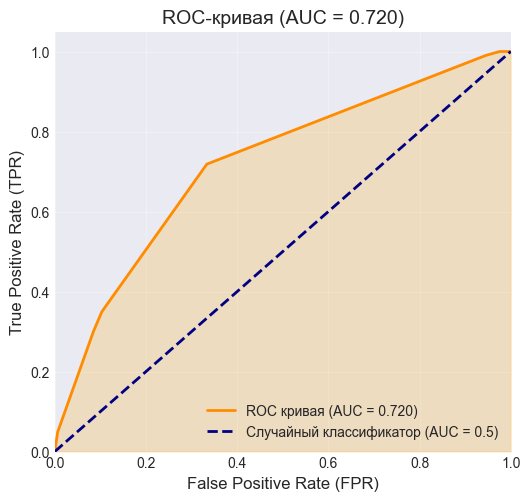

In [71]:
fig = plt.figure(figsize=(20, 12))

ax1 = plt.subplot(2, 3, 1)
ax1.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC кривая (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Случайный классификатор (AUC = 0.5)')
ax1.fill_between(fpr, tpr, alpha=0.2, color='orange')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title(f'ROC-кривая (AUC = {roc_auc:.3f})', fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

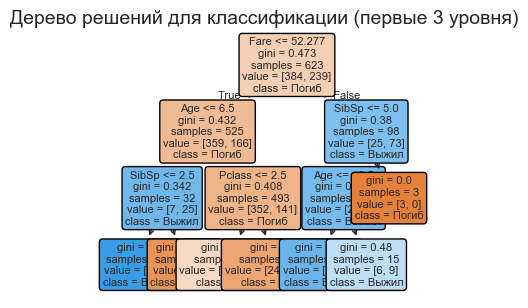

In [72]:
ax6 = plt.subplot(2, 3, 6)
plot_tree(best_classifier, feature_names=X.columns, 
          class_names=['Погиб', 'Выжил'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
ax6.set_title('Дерево решений для классификации (первые 3 уровня)', fontsize=14)

plt.tight_layout()
plt.show()